In [9]:
# ============================================================================
# EEG Sleep Staging — Multi-Algorithm Comparison
# ============================================================================
# Dataset:    PhysioNet Sleep-EDF (83 subjects, both recording nights, ~160 recordings)
# Task:       5-class sleep stage classification (W, N1, N2, N3, REM)
# Models:     Random Forest, SVM, XGBoost, 1D CNN, BiLSTM, CNN+LSTM
# Evaluation: Accuracy, F1-score, Cohen's Kappa, Confusion Matrices, Hypnograms
# ============================================================================

In [1]:
# === IMPORTS ===
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
from collections import Counter

from scipy.signal import welch
from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, cohen_kappa_score)
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from mne.datasets.sleep_physionet.age import fetch_data

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"MNE: {mne.__version__}, PyTorch: {torch.__version__}")
print(f"Device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))

MNE: 1.11.0, PyTorch: 2.5.1+cu121
Device: cuda (NVIDIA GeForce RTX 3050 Laptop GPU)


In [2]:
# === CONSTANTS ===

STAGE_MAP = {
    'Sleep stage W': 'W',
    'Sleep stage 1': 'N1',
    'Sleep stage 2': 'N2',
    'Sleep stage 3': 'N3',
    'Sleep stage 4': 'N3',   # merge Stage 4 into N3 (deep sleep)
    'Sleep stage R': 'REM',
    'Movement time': None,   # skip
    'Sleep stage ?': None    # skip
}

STAGE_ORDER = ['W', 'N1', 'N2', 'N3', 'REM']
STAGE_TO_INT = {s: i for i, s in enumerate(STAGE_ORDER)}
INT_TO_STAGE = {i: s for s, i in STAGE_TO_INT.items()}

FREQ_BANDS = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'sigma': (12, 15),
    'beta':  (13, 30)
}

EPOCH_SEC = 30
EEG_CHANNEL = 'EEG Fpz-Cz'

print("Stage mapping:", STAGE_TO_INT)
print("Frequency bands:", FREQ_BANDS)

Stage mapping: {'W': 0, 'N1': 1, 'N2': 2, 'N3': 3, 'REM': 4}
Frequency bands: {'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 13), 'sigma': (12, 15), 'beta': (13, 30)}


## Phase 1 — Data Loading

Fetch all available subjects from **PhysioNet Sleep-EDF** (both recording nights).  
Using `on_missing="ignore"` to skip subjects with missing recordings.

In [6]:
import glob, re, os

# ── Build PSG/Hypnogram pairs directly from cached files ──
cache_dir = os.path.expanduser("~/mne_data/physionet-sleep-data")

psg_files  = sorted(glob.glob(os.path.join(cache_dir, "SC*-PSG.edf")))
hyp_files  = sorted(glob.glob(os.path.join(cache_dir, "SC*-Hypnogram.edf")))

# Index hypnogram files by their base prefix (e.g. "SC4001")
hyp_map = {}
for h in hyp_files:
    base = os.path.basename(h)
    prefix = base.split("E")[0]          # "SC4001"
    hyp_map[prefix] = h

# Match each PSG with its hypnogram
records = []
for p in psg_files:
    base = os.path.basename(p)
    prefix = base.split("E")[0]          # "SC4001"
    if prefix in hyp_map:
        records.append([p, hyp_map[prefix]])

print(f"Found {len(records)} valid cached PSG + Hypnogram pairs")
for i, (psg, hyp) in enumerate(records[:5]):
    print(f"  [{i}] {os.path.basename(psg)}  +  {os.path.basename(hyp)}")
if len(records) > 5:
    print(f"  ... and {len(records)-5} more")

Found 54 valid cached PSG + Hypnogram pairs
  [0] SC4001E0-PSG.edf  +  SC4001EC-Hypnogram.edf
  [1] SC4002E0-PSG.edf  +  SC4002EC-Hypnogram.edf
  [2] SC4011E0-PSG.edf  +  SC4011EH-Hypnogram.edf
  [3] SC4012E0-PSG.edf  +  SC4012EC-Hypnogram.edf
  [4] SC4021E0-PSG.edf  +  SC4021EH-Hypnogram.edf
  ... and 49 more


## Phase 2 — Per-Epoch Feature Extraction

Extract **~20 features** per 30-second EEG epoch from the `Fpz-Cz` channel:

| Feature Group | Count | Description |
|--------------|-------|-------------|
| Band Powers | 5 | Delta, Theta, Alpha, Sigma, Beta |
| Relative Powers | 5 | Each band / total power |
| Spectral | 2 | Spectral entropy, Theta/Alpha ratio |
| Hjorth | 3 | Activity, Mobility, Complexity |
| Statistical | 4 | Mean, Std, Skewness, Kurtosis |
| Total Power | 1 | Integrated PSD |

In [7]:
# === PER-EPOCH FEATURE EXTRACTION FUNCTION ===

def extract_epoch_features(epoch_data, sfreq):
    """Extract ~20 features from a single 30-second EEG epoch.
    
    Features:
    - 5 absolute band powers (delta, theta, alpha, sigma, beta)
    - 5 relative band powers
    - Spectral entropy
    - 3 Hjorth parameters (activity, mobility, complexity)
    - 4 statistical features (mean, std, skewness, kurtosis)
    - Total power
    - Theta/Alpha ratio (drowsiness indicator)
    """
    features = {}
    
    # --- PSD via Welch ---
    nperseg = min(int(2 * sfreq), len(epoch_data))  # 2-sec windows
    freqs, psd = welch(epoch_data, fs=sfreq, nperseg=nperseg, noverlap=nperseg // 2)
    
    # Total power
    total_power = np.trapezoid(psd, freqs)
    features['total_power'] = total_power
    
    # Band powers (absolute and relative)
    for band_name, (fmin, fmax) in FREQ_BANDS.items():
        band_mask = (freqs >= fmin) & (freqs < fmax)
        band_power = np.trapezoid(psd[band_mask], freqs[band_mask]) if band_mask.any() else 0
        features[f'{band_name}_power'] = band_power
        features[f'{band_name}_rel_power'] = band_power / (total_power + 1e-12)
    
    # Theta/Alpha ratio (drowsiness indicator)
    features['theta_alpha_ratio'] = features['theta_power'] / (features['alpha_power'] + 1e-12)
    
    # --- Spectral Entropy ---
    psd_norm = psd / (psd.sum() + 1e-12)
    psd_norm = psd_norm[psd_norm > 0]
    features['spectral_entropy'] = -np.sum(psd_norm * np.log2(psd_norm))
    
    # --- Hjorth Parameters ---
    activity = np.var(epoch_data)
    features['hjorth_activity'] = activity
    
    diff1 = np.diff(epoch_data)
    mobility = np.std(diff1) / (np.std(epoch_data) + 1e-12)
    features['hjorth_mobility'] = mobility
    
    diff2 = np.diff(diff1)
    mob_d1 = np.std(diff2) / (np.std(diff1) + 1e-12)
    features['hjorth_complexity'] = mob_d1 / (mobility + 1e-12)
    
    # --- Statistical Features ---
    features['epoch_mean'] = np.mean(epoch_data)
    features['epoch_std'] = np.std(epoch_data)
    features['epoch_skewness'] = float(skew(epoch_data))
    features['epoch_kurtosis'] = float(kurtosis(epoch_data))
    
    return features

# Quick validation
test_signal = np.random.randn(3000)
test_feat = extract_epoch_features(test_signal, 100)
print(f"Features per epoch: {len(test_feat)}")
print(f"Feature names: {list(test_feat.keys())}")

Features per epoch: 20
Feature names: ['total_power', 'delta_power', 'delta_rel_power', 'theta_power', 'theta_rel_power', 'alpha_power', 'alpha_rel_power', 'sigma_power', 'sigma_rel_power', 'beta_power', 'beta_rel_power', 'theta_alpha_ratio', 'spectral_entropy', 'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity', 'epoch_mean', 'epoch_std', 'epoch_skewness', 'epoch_kurtosis']


In [ ]:
# === MAIN EXTRACTION LOOP ===
# Process all recordings: extract features + raw epochs per 30-sec window

all_features = []       # For classical ML (feature-based)
all_raw_epochs = []     # For deep learning (raw signal)
all_labels = []         # Sleep stage labels (int)
all_subject_ids = []    # For subject-level splitting
failed_recordings = []

import time as _time
_loop_start = _time.time()

for rec_idx, (psg_path, hypno_path) in enumerate(records):
    # Extract subject ID from filename (e.g., "SC4001E0-PSG.edf" → "SC4001")
    basename = os.path.basename(psg_path)
    subject_id = basename[:6]  # e.g., "SC4001"
    _rec_start = _time.time()
    
    try:
        # Load raw EEG
        raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
        sfreq = raw.info['sfreq']
        annotations = mne.read_annotations(hypno_path)
        raw.set_annotations(annotations)
        
        # Convert annotations to events
        events, event_id = mne.events_from_annotations(raw, verbose=False)
        
        # Create proper non-overlapping 30-sec epochs 
        tmax = EPOCH_SEC - (1.0 / sfreq)
        epochs = mne.Epochs(
            raw, events, event_id=event_id,
            tmin=0, tmax=tmax,
            baseline=None, preload=True,
            picks=[EEG_CHANNEL],
            verbose=False
        )
        
        epoch_count = 0
        # Process each epoch
        for ep_idx in range(len(epochs)):
            ev = epochs.events[ep_idx]
            # Map event to sleep stage
            stage_name = [k for k, v in event_id.items() if v == ev[2]]
            if not stage_name:
                continue
            stage_name = stage_name[0]
            if stage_name not in STAGE_MAP or STAGE_MAP[stage_name] is None:
                continue
            stage = STAGE_MAP[stage_name]
            
            # Get epoch data (single channel)
            try:
                ep_data = epochs[ep_idx].get_data(copy=True)[0, 0, :]
            except Exception:
                continue
            
            # Extract features for classical ML
            feats = extract_epoch_features(ep_data, sfreq)
            feats['subject_id'] = subject_id
            feats['stage'] = stage
            feats['stage_int'] = STAGE_TO_INT[stage]
            feats['epoch_idx'] = ep_idx
            feats['recording'] = rec_idx
            
            all_features.append(feats)
            all_raw_epochs.append(ep_data)
            all_labels.append(STAGE_TO_INT[stage])
            all_subject_ids.append(subject_id)
            epoch_count += 1
        
        _rec_time = _time.time() - _rec_start
        _elapsed = _time.time() - _loop_start
        _avg_per_rec = _elapsed / (rec_idx + 1)
        _remaining = _avg_per_rec * (len(records) - rec_idx - 1)
        print(f"✅ [{rec_idx+1}/{len(records)}] {subject_id} — {epoch_count} epochs "
              f"({_rec_time:.1f}s) | Elapsed: {_elapsed/60:.1f}min | ETA: {_remaining/60:.1f}min")
    
    except Exception as e:
        failed_recordings.append((rec_idx, basename, str(e)))
        print(f"❌ [{rec_idx+1}/{len(records)}] {basename} — {e}")

_total_time = _time.time() - _loop_start

# Convert to DataFrame
df_features = pd.DataFrame(all_features)
print(f"\n{'='*60}")
print(f"Extraction complete in {_total_time/60:.1f} minutes ({_total_time:.0f}s)")
print(f"Total epochs: {len(df_features)}")
print(f"Unique subjects: {df_features['subject_id'].nunique()}")
print(f"Failed recordings: {len(failed_recordings)}")
print(f"Avg time per recording: {_total_time/len(records):.1f}s")
print(f"\nClass distribution:")
print(df_features['stage'].value_counts().reindex(STAGE_ORDER))

✅ [1/54] SC4001 — 153 epochs (3.3s) | Elapsed: 0.1min | ETA: 2.9min
✅ [2/54] SC4002 — 150 epochs (4.7s) | Elapsed: 0.1min | ETA: 3.5min
✅ [3/54] SC4011 — 125 epochs (5.3s) | Elapsed: 0.2min | ETA: 3.8min
✅ [4/54] SC4012 — 170 epochs (2.8s) | Elapsed: 0.3min | ETA: 3.4min
✅ [5/54] SC4021 — 160 epochs (6.3s) | Elapsed: 0.4min | ETA: 3.7min
✅ [6/54] SC4022 — 177 epochs (3.1s) | Elapsed: 0.4min | ETA: 3.4min
✅ [7/54] SC4031 — 118 epochs (2.5s) | Elapsed: 0.5min | ETA: 3.1min
✅ [8/54] SC4032 — 122 epochs (6.6s) | Elapsed: 0.6min | ETA: 3.3min
✅ [9/54] SC4041 — 159 epochs (4.3s) | Elapsed: 0.7min | ETA: 3.3min
✅ [10/54] SC4042 — 173 epochs (5.1s) | Elapsed: 0.7min | ETA: 3.2min
✅ [11/54] SC4051 — 129 epochs (10.5s) | Elapsed: 0.9min | ETA: 3.6min
✅ [12/54] SC4052 — 136 epochs (3.1s) | Elapsed: 1.0min | ETA: 3.4min
✅ [13/54] SC4061 — 77 epochs (3.5s) | Elapsed: 1.0min | ETA: 3.2min
✅ [14/54] SC4062 — 97 epochs (3.7s) | Elapsed: 1.1min | ETA: 3.1min
✅ [15/54] SC4071 — 115 epochs (3.7s) | Elaps

 27%|########7                        | 11.8M/44.5M [1:06:47<3:04:12, 2.96kB/s]
 28%|#########7                         | 12.4M/44.5M [31:40<1:21:59, 6.53kB/s]


✅ [27/54] SC4131 — 146 epochs (3.3s) | Elapsed: 2.3min | ETA: 2.3min
✅ [28/54] SC4141 — 121 epochs (2.8s) | Elapsed: 2.4min | ETA: 2.2min
✅ [29/54] SC4142 — 123 epochs (3.1s) | Elapsed: 2.4min | ETA: 2.1min
✅ [30/54] SC4151 — 94 epochs (2.9s) | Elapsed: 2.5min | ETA: 2.0min
✅ [31/54] SC4152 — 101 epochs (3.4s) | Elapsed: 2.5min | ETA: 1.9min
✅ [32/54] SC4161 — 150 epochs (3.2s) | Elapsed: 2.6min | ETA: 1.8min
✅ [33/54] SC4162 — 132 epochs (2.7s) | Elapsed: 2.6min | ETA: 1.7min
✅ [34/54] SC4171 — 181 epochs (5.2s) | Elapsed: 2.7min | ETA: 1.6min
✅ [35/54] SC4172 — 185 epochs (3.9s) | Elapsed: 2.8min | ETA: 1.5min
✅ [36/54] SC4181 — 160 epochs (3.1s) | Elapsed: 2.8min | ETA: 1.4min
✅ [37/54] SC4182 — 107 epochs (2.8s) | Elapsed: 2.9min | ETA: 1.3min
✅ [38/54] SC4191 — 177 epochs (3.4s) | Elapsed: 2.9min | ETA: 1.2min
✅ [39/54] SC4192 — 123 epochs (2.4s) | Elapsed: 3.0min | ETA: 1.1min
✅ [40/54] SC4201 — 54 epochs (6.4s) | Elapsed: 3.1min | ETA: 1.1min
✅ [41/54] SC4202 — 46 epochs (2.5s) 

In [9]:
# === SAVE EXTRACTED FEATURES ===
df_features.to_csv("eeg_epochs_features.csv", index=False)
print(f"Saved {len(df_features)} epochs × {len(df_features.columns)} columns to eeg_epochs_features.csv")
print(f"\nFeature columns: {[c for c in df_features.columns if c not in ['subject_id','stage','stage_int','epoch_idx','recording']]}")
print(f"\nSample data:")
df_features.head()

Saved 7086 epochs × 25 columns to eeg_epochs_features.csv

Feature columns: ['total_power', 'delta_power', 'delta_rel_power', 'theta_power', 'theta_rel_power', 'alpha_power', 'alpha_rel_power', 'sigma_power', 'sigma_rel_power', 'beta_power', 'beta_rel_power', 'theta_alpha_ratio', 'spectral_entropy', 'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity', 'epoch_mean', 'epoch_std', 'epoch_skewness', 'epoch_kurtosis']

Sample data:


,total_power,delta_power,delta_rel_power,theta_power,theta_rel_power,alpha_power,alpha_rel_power,sigma_power,sigma_rel_power,beta_power,...,hjorth_complexity,epoch_mean,epoch_std,epoch_skewness,epoch_kurtosis,subject_id,stage,stage_int,epoch_idx,recording
0,1.057690e-09,6.431621e-10,0.607508,9.640291e-11,0.091059,9.233046e-12,0.008721,2.072995e-12,0.001958,9.912234e-12,...,6.156786,4.087560e-07,0.000036,0.269926,2.337749,SC4001,W,0,0,0
1,7.447759e-11,3.568651e-11,0.472809,1.559757e-11,0.206652,8.351297e-12,0.110646,1.196370e-12,0.015851,3.372998e-12,...,2.769623,2.302437e-07,0.000009,0.210865,1.269998,SC4001,N1,1,1,0
2,2.538046e-10,1.677617e-10,0.658393,3.724636e-11,0.146176,3.808226e-12,0.014946,1.044448e-12,0.004099,3.187061e-12,...,4.107617,2.600322e-07,0.000017,-0.022893,2.157798,SC4001,N2,2,2,0
3,5.550064e-10,4.024208e-10,0.723770,5.887565e-11,0.105890,1.157466e-11,0.020818,8.039667e-12,0.014460,6.778517e-12,...,3.726417,2.109890e-07,0.000024,0.175496,0.678972,SC4001,N3,3,3,0
4,3.887398e-10,2.945161e-10,0.755674,3.840748e-11,0.098546,9.583416e-12,0.024589,4.566615e-12,0.011717,4.588161e-12,...,3.925466,3.416459e-07,0.000020,0.098239,0.228959,SC4001,N2,2,4,0


In [10]:
# ============================================================================
# Phase 3 — Subject-Level Data Splitting
# ============================================================================
# Split by SUBJECT ID (not by epoch) to prevent data leakage.
# Both nights of the same subject stay in the same split.
# Train: 70% | Validation: 15% | Test: 15%
# ============================================================================

In [11]:
# === SUBJECT-LEVEL TRAIN / VAL / TEST SPLIT ===
unique_subjects = df_features['subject_id'].unique()
np.random.seed(42)
np.random.shuffle(unique_subjects)

n = len(unique_subjects)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

train_subjects = set(unique_subjects[:n_train])
val_subjects = set(unique_subjects[n_train:n_train + n_val])
test_subjects = set(unique_subjects[n_train + n_val:])

# Verify no data leakage
assert len(train_subjects & val_subjects) == 0, "Leakage: train ∩ val"
assert len(train_subjects & test_subjects) == 0, "Leakage: train ∩ test"
assert len(val_subjects & test_subjects) == 0, "Leakage: val ∩ test"

# Create masks
train_mask = df_features['subject_id'].isin(train_subjects)
val_mask = df_features['subject_id'].isin(val_subjects)
test_mask = df_features['subject_id'].isin(test_subjects)

print(f"Subjects — Train: {len(train_subjects)}, Val: {len(val_subjects)}, Test: {len(test_subjects)}")
print(f"Epochs   — Train: {train_mask.sum()}, Val: {val_mask.sum()}, Test: {test_mask.sum()}")
print(f"\nClass distribution per split:")
for name, mask in [('Train', train_mask), ('Val', val_mask), ('Test', test_mask)]:
    counts = df_features.loc[mask, 'stage'].value_counts().reindex(STAGE_ORDER)
    pcts = (counts / counts.sum() * 100).round(1)
    print(f"  {name}: {dict(zip(STAGE_ORDER, [f'{c} ({p}%)' for c, p in zip(counts, pcts)]))}") 

Subjects — Train: 37, Val: 8, Test: 9
Epochs   — Train: 5095, Val: 992, Test: 999

Class distribution per split:
  Train: {'W': '626 (12.3%)', 'N1': '1133 (22.2%)', 'N2': '1528 (30.0%)', 'N3': '1382 (27.1%)', 'REM': '426 (8.4%)'}
  Val: {'W': '106 (10.7%)', 'N1': '159 (16.0%)', 'N2': '348 (35.1%)', 'N3': '331 (33.4%)', 'REM': '48 (4.8%)'}
  Test: {'W': '140 (14.0%)', 'N1': '208 (20.8%)', 'N2': '313 (31.3%)', 'N3': '248 (24.8%)', 'REM': '90 (9.0%)'}


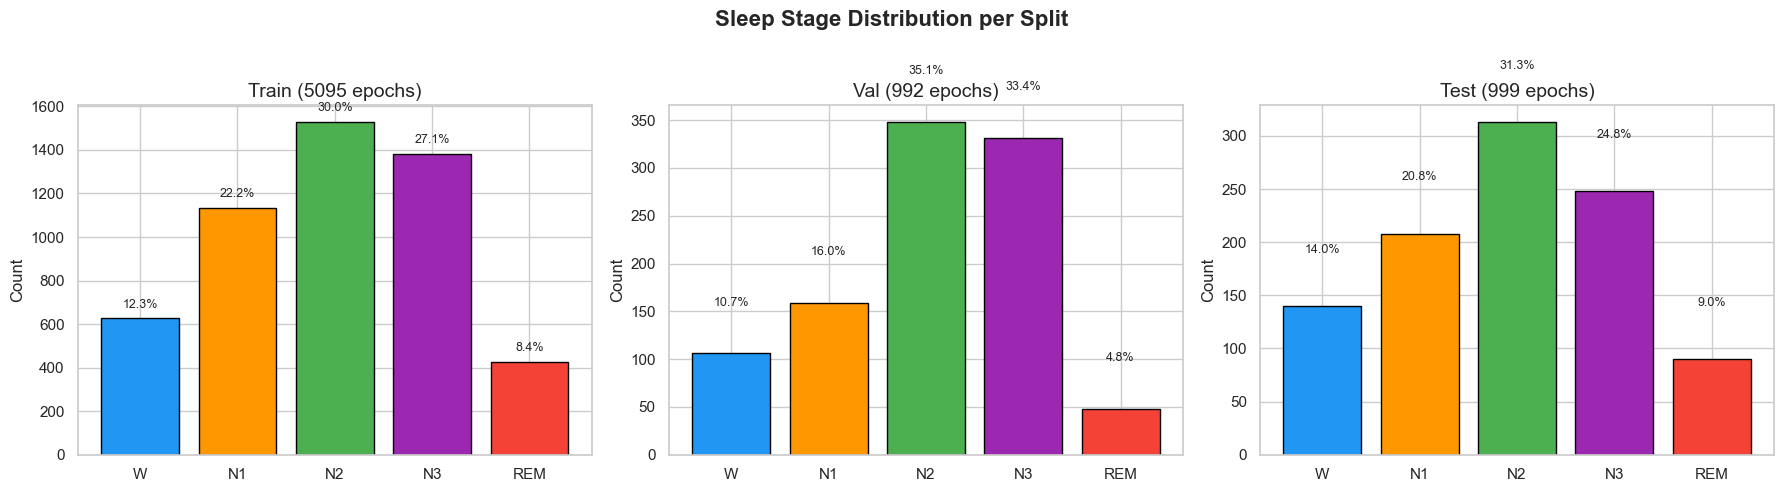


Class weights for imbalance handling:
  W: 1.628
  N1: 0.899
  N2: 0.667
  N3: 0.737
  REM: 2.392


In [12]:
# === CLASS BALANCE VISUALIZATION ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Sleep Stage Distribution per Split', fontsize=16, fontweight='bold')

colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336']

for ax, (name, mask) in zip(axes, [('Train', train_mask), ('Val', val_mask), ('Test', test_mask)]):
    counts = df_features.loc[mask, 'stage'].value_counts().reindex(STAGE_ORDER)
    ax.bar(STAGE_ORDER, counts.values, color=colors, edgecolor='black')
    ax.set_title(f'{name} ({mask.sum()} epochs)', fontsize=14)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, f'{v/mask.sum()*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Compute class weights for imbalanced training
all_train_labels = df_features.loc[train_mask, 'stage_int'].values
class_weights_array = compute_class_weight('balanced', classes=np.arange(5), y=all_train_labels)
class_weight_dict = dict(zip(range(5), class_weights_array))

print(f"\nClass weights for imbalance handling:")
for cls_idx, weight in class_weight_dict.items():
    print(f"  {INT_TO_STAGE[cls_idx]}: {weight:.3f}")

In [13]:
# ============================================================================
# Phase 4 — Classical Machine Learning Models
# ============================================================================
# Feature-based classification using extracted spectral, Hjorth & statistical features.
# Models: Random Forest (~80%), SVM (~78%), XGBoost (~82%)
# ============================================================================

In [14]:
# === PREPARE FEATURE MATRIX FOR CLASSICAL ML ===

feature_cols = [c for c in df_features.columns
                if c not in ['subject_id', 'stage', 'stage_int', 'epoch_idx', 'recording']]

X_train_ml = df_features.loc[train_mask, feature_cols].values.astype(np.float32)
X_val_ml = df_features.loc[val_mask, feature_cols].values.astype(np.float32)
X_test_ml = df_features.loc[test_mask, feature_cols].values.astype(np.float32)

y_train_ml = df_features.loc[train_mask, 'stage_int'].values
y_val_ml = df_features.loc[val_mask, 'stage_int'].values
y_test_ml = df_features.loc[test_mask, 'stage_int'].values

# Scale features (fit on train only)
scaler = StandardScaler()
X_train_ml = scaler.fit_transform(X_train_ml)
X_val_ml = scaler.transform(X_val_ml)
X_test_ml = scaler.transform(X_test_ml)

# Handle any NaN/Inf from feature extraction
X_train_ml = np.nan_to_num(X_train_ml, nan=0, posinf=0, neginf=0)
X_val_ml = np.nan_to_num(X_val_ml, nan=0, posinf=0, neginf=0)
X_test_ml = np.nan_to_num(X_test_ml, nan=0, posinf=0, neginf=0)

print(f"ML Feature matrix shapes:")
print(f"  Train: {X_train_ml.shape}, Val: {X_val_ml.shape}, Test: {X_test_ml.shape}")
print(f"  Features ({len(feature_cols)}): {feature_cols}")

# Store results for comparison
results = {}

ML Feature matrix shapes:
  Train: (5095, 20), Val: (992, 20), Test: (999, 20)
  Features (20): ['total_power', 'delta_power', 'delta_rel_power', 'theta_power', 'theta_rel_power', 'alpha_power', 'alpha_rel_power', 'sigma_power', 'sigma_rel_power', 'beta_power', 'beta_rel_power', 'theta_alpha_ratio', 'spectral_entropy', 'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity', 'epoch_mean', 'epoch_std', 'epoch_skewness', 'epoch_kurtosis']


In [15]:
# === MODEL 1: RANDOM FOREST ===
print("Training Random Forest...")
t0 = time.time()

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_ml, y_train_ml)
train_time = time.time() - t0

# Predict
y_pred_rf = rf_model.predict(X_test_ml)

# Evaluate
rf_acc = accuracy_score(y_test_ml, y_pred_rf)
rf_f1_macro = f1_score(y_test_ml, y_pred_rf, average='macro')
rf_f1_weighted = f1_score(y_test_ml, y_pred_rf, average='weighted')
rf_kappa = cohen_kappa_score(y_test_ml, y_pred_rf)

results['Random Forest'] = {
    'accuracy': rf_acc, 'f1_macro': rf_f1_macro, 'f1_weighted': rf_f1_weighted,
    'kappa': rf_kappa, 'train_time': train_time,
    'y_pred': y_pred_rf, 'y_true': y_test_ml
}

print(f"\n{'='*50}")
print(f"Random Forest Results (train time: {train_time:.1f}s)")
print(f"{'='*50}")
print(f"Accuracy:       {rf_acc:.4f}")
print(f"F1 (macro):     {rf_f1_macro:.4f}")
print(f"F1 (weighted):  {rf_f1_weighted:.4f}")
print(f"Cohen's Kappa:  {rf_kappa:.4f}")
print(f"\n{classification_report(y_test_ml, y_pred_rf, target_names=STAGE_ORDER)}")

Training Random Forest...

Random Forest Results (train time: 0.9s)
Accuracy:       0.6717
F1 (macro):     0.6451
F1 (weighted):  0.6741
Cohen's Kappa:  0.5712

              precision    recall  f1-score   support

           W       0.73      0.56      0.64       140
          N1       0.52      0.77      0.62       208
          N2       0.67      0.67      0.67       313
          N3       0.89      0.75      0.81       248
         REM       0.59      0.41      0.48        90

    accuracy                           0.67       999
   macro avg       0.68      0.63      0.65       999
weighted avg       0.70      0.67      0.67       999



In [16]:
# === MODEL 2: SVM ===
print("Training SVM (RBF kernel)...")
t0 = time.time()

svm_model = SVC(
    kernel='rbf',
    C=10.0,
    gamma='scale',
    class_weight='balanced',
    random_state=42,
    decision_function_shape='ovr'
)
svm_model.fit(X_train_ml, y_train_ml)
train_time = time.time() - t0

# Predict
y_pred_svm = svm_model.predict(X_test_ml)

# Evaluate
svm_acc = accuracy_score(y_test_ml, y_pred_svm)
svm_f1_macro = f1_score(y_test_ml, y_pred_svm, average='macro')
svm_f1_weighted = f1_score(y_test_ml, y_pred_svm, average='weighted')
svm_kappa = cohen_kappa_score(y_test_ml, y_pred_svm)

results['SVM'] = {
    'accuracy': svm_acc, 'f1_macro': svm_f1_macro, 'f1_weighted': svm_f1_weighted,
    'kappa': svm_kappa, 'train_time': train_time,
    'y_pred': y_pred_svm, 'y_true': y_test_ml
}

print(f"\n{'='*50}")
print(f"SVM Results (train time: {train_time:.1f}s)")
print(f"{'='*50}")
print(f"Accuracy:       {svm_acc:.4f}")
print(f"F1 (macro):     {svm_f1_macro:.4f}")
print(f"F1 (weighted):  {svm_f1_weighted:.4f}")
print(f"Cohen's Kappa:  {svm_kappa:.4f}")
print(f"\n{classification_report(y_test_ml, y_pred_svm, target_names=STAGE_ORDER)}")

Training SVM (RBF kernel)...

SVM Results (train time: 0.6s)
Accuracy:       0.6607
F1 (macro):     0.6443
F1 (weighted):  0.6668
Cohen's Kappa:  0.5669

              precision    recall  f1-score   support

           W       0.63      0.75      0.69       140
          N1       0.54      0.60      0.57       208
          N2       0.73      0.58      0.65       313
          N3       0.88      0.78      0.83       248
         REM       0.41      0.61      0.49        90

    accuracy                           0.66       999
   macro avg       0.64      0.66      0.64       999
weighted avg       0.68      0.66      0.67       999



In [17]:
# === MODEL 3: XGBOOST ===
print("Training XGBoost...")
t0 = time.time()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

# Apply sample weights for class imbalance
sample_weights = np.array([class_weight_dict[y] for y in y_train_ml])
xgb_model.fit(X_train_ml, y_train_ml, sample_weight=sample_weights)
train_time = time.time() - t0

# Predict
y_pred_xgb = xgb_model.predict(X_test_ml)

# Evaluate
xgb_acc = accuracy_score(y_test_ml, y_pred_xgb)
xgb_f1_macro = f1_score(y_test_ml, y_pred_xgb, average='macro')
xgb_f1_weighted = f1_score(y_test_ml, y_pred_xgb, average='weighted')
xgb_kappa = cohen_kappa_score(y_test_ml, y_pred_xgb)

results['XGBoost'] = {
    'accuracy': xgb_acc, 'f1_macro': xgb_f1_macro, 'f1_weighted': xgb_f1_weighted,
    'kappa': xgb_kappa, 'train_time': train_time,
    'y_pred': y_pred_xgb, 'y_true': y_test_ml
}

print(f"\n{'='*50}")
print(f"XGBoost Results (train time: {train_time:.1f}s)")
print(f"{'='*50}")
print(f"Accuracy:       {xgb_acc:.4f}")
print(f"F1 (macro):     {xgb_f1_macro:.4f}")
print(f"F1 (weighted):  {xgb_f1_weighted:.4f}")
print(f"Cohen's Kappa:  {xgb_kappa:.4f}")
print(f"\n{classification_report(y_test_ml, y_pred_xgb, target_names=STAGE_ORDER)}")

Training XGBoost...

XGBoost Results (train time: 3.7s)
Accuracy:       0.6597
F1 (macro):     0.6268
F1 (weighted):  0.6613
Cohen's Kappa:  0.5562

              precision    recall  f1-score   support

           W       0.62      0.59      0.61       140
          N1       0.52      0.70      0.60       208
          N2       0.68      0.67      0.67       313
          N3       0.87      0.75      0.81       248
         REM       0.55      0.38      0.45        90

    accuracy                           0.66       999
   macro avg       0.65      0.62      0.63       999
weighted avg       0.67      0.66      0.66       999



## Phase 5 — Deep Learning Models

Raw EEG signal input (no manual feature extraction).

| Model | Architecture | Strategy |
|-------|-------------|----------|
| 1D CNN | Conv1D → BN → MaxPool (×3) → GAP → Dense | Learns spatial patterns |
| BiLSTM | Bidirectional LSTM → Dense | Captures temporal dependencies |
| CNN+LSTM | TimeDistributed CNN → LSTM | Best of both: features + transitions |

In [18]:
# === PREPARE RAW EEG DATA FOR DEEP LEARNING (PyTorch) ===

labels_array = np.array(all_labels, dtype=np.int64)
subjects_array = np.array(all_subject_ids)

# Determine consistent epoch length (pad/truncate to most common length)
actual_lengths = [len(ep) for ep in all_raw_epochs]
common_len = max(set(actual_lengths), key=actual_lengths.count)
print(f"Most common epoch length: {common_len} samples")
target_len = common_len

# Pad or truncate all epochs to the same length
X_dl = np.zeros((len(all_raw_epochs), target_len), dtype=np.float32)
for i, ep in enumerate(all_raw_epochs):
    ep_len = min(len(ep), target_len)
    X_dl[i, :ep_len] = ep[:ep_len]

# Normalize per-epoch (z-score)
ep_mean = X_dl.mean(axis=1, keepdims=True)
ep_std = X_dl.std(axis=1, keepdims=True) + 1e-8
X_dl = (X_dl - ep_mean) / ep_std

# Split by subject (same as ML split)
train_dl_mask = np.array([s in train_subjects for s in subjects_array])
val_dl_mask = np.array([s in val_subjects for s in subjects_array])
test_dl_mask = np.array([s in test_subjects for s in subjects_array])

# PyTorch tensors: (N, 1, timesteps) — channels-first for Conv1d
X_train_dl = torch.tensor(X_dl[train_dl_mask]).unsqueeze(1).to(device)
X_val_dl = torch.tensor(X_dl[val_dl_mask]).unsqueeze(1).to(device)
X_test_dl = torch.tensor(X_dl[test_dl_mask]).unsqueeze(1).to(device)

y_train_dl = torch.tensor(labels_array[train_dl_mask]).to(device)
y_val_dl = torch.tensor(labels_array[val_dl_mask]).to(device)
y_test_dl_int = labels_array[test_dl_mask]  # keep numpy for sklearn metrics

# DataLoaders
train_dataset = TensorDataset(X_train_dl, y_train_dl)
val_dataset = TensorDataset(X_val_dl, y_val_dl)
test_dataset = TensorDataset(X_test_dl, torch.tensor(y_test_dl_int).to(device))

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Class weights for loss function
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float32).to(device)

print(f"\nDL Data shapes (PyTorch, channels-first):")
print(f"  X_train: {X_train_dl.shape}, y_train: {y_train_dl.shape}")
print(f"  X_val:   {X_val_dl.shape},   y_val:   {y_val_dl.shape}")
print(f"  X_test:  {X_test_dl.shape},  y_test:  {y_test_dl_int.shape}")
print(f"  Device:  {device}")

# --- Helper: Train & Evaluate a PyTorch model ---
def train_pytorch_model(model, train_loader, val_loader, epochs=50, lr=1e-3,
                        patience=10, lr_patience=5, model_name='model'):
    """Train a PyTorch model with early stopping and LR scheduling."""
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                      factor=0.5, patience=lr_patience, verbose=True)

    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * X_batch.size(0)
            correct += (out.argmax(1) == y_batch).sum().item()
            total += X_batch.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)

        # --- Validate ---
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                out = model(X_batch)
                loss = criterion(out, y_batch)
                val_loss_sum += loss.item() * X_batch.size(0)
                val_correct += (out.argmax(1) == y_batch).sum().item()
                val_total += X_batch.size(0)

        val_loss = val_loss_sum / val_total
        val_acc = val_correct / val_total
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        scheduler.step(val_loss)

        print(f"  Epoch {epoch+1:3d}/{epochs} — loss: {train_loss:.4f}, acc: {train_acc:.4f} "
              f"| val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    return history


def predict_pytorch(model, data_loader):
    """Get predictions from a PyTorch model."""
    model.eval()
    all_preds = []
    with torch.no_grad():
        for X_batch, _ in data_loader:
            out = model(X_batch)
            all_preds.append(out.argmax(1).cpu().numpy())
    return np.concatenate(all_preds)

Most common epoch length: 3000 samples

DL Data shapes (PyTorch, channels-first):
  X_train: torch.Size([5095, 1, 3000]), y_train: torch.Size([5095])
  X_val:   torch.Size([992, 1, 3000]),   y_val:   torch.Size([992])
  X_test:  torch.Size([999, 1, 3000]),  y_test:  (999,)
  Device:  cuda


In [19]:
# === MODEL 4: 1D CNN (PyTorch) ===
print("Building 1D CNN on", device, "...")

n_timesteps = X_train_dl.shape[2]  # channels-first: (N, 1, timesteps)

class CNN1D(nn.Module):
    def __init__(self, n_timesteps):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=50, stride=6, padding=25),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(8),
            nn.Conv1d(64, 128, kernel_size=25, stride=1, padding=12),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(8),
            nn.Conv1d(128, 256, kernel_size=10, padding=5),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.AdaptiveAvgPool1d(1),  # Global Average Pooling
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 5),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn_model = CNN1D(n_timesteps).to(device)
print(cnn_model)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"Total parameters: {total_params:,}")

# Train
t0 = time.time()
history_cnn = train_pytorch_model(cnn_model, train_loader, val_loader,
                                   epochs=50, lr=1e-3, patience=10, model_name='CNN_1D')
cnn_train_time = time.time() - t0

# Evaluate
y_pred_cnn = predict_pytorch(cnn_model, test_loader)

cnn_acc = accuracy_score(y_test_dl_int, y_pred_cnn)
cnn_f1_macro = f1_score(y_test_dl_int, y_pred_cnn, average='macro')
cnn_f1_weighted = f1_score(y_test_dl_int, y_pred_cnn, average='weighted')
cnn_kappa = cohen_kappa_score(y_test_dl_int, y_pred_cnn)

results['1D CNN'] = {
    'accuracy': cnn_acc, 'f1_macro': cnn_f1_macro, 'f1_weighted': cnn_f1_weighted,
    'kappa': cnn_kappa, 'train_time': cnn_train_time,
    'y_pred': y_pred_cnn, 'y_true': y_test_dl_int, 'history': history_cnn
}

print(f"\n{'='*50}")
print(f"1D CNN Results (train time: {cnn_train_time:.1f}s, device: {device})")
print(f"{'='*50}")
print(f"Accuracy:       {cnn_acc:.4f}")
print(f"F1 (macro):     {cnn_f1_macro:.4f}")
print(f"F1 (weighted):  {cnn_f1_weighted:.4f}")
print(f"Cohen's Kappa:  {cnn_kappa:.4f}")
print(f"\n{classification_report(y_test_dl_int, y_pred_cnn, target_names=STAGE_ORDER)}")

Building 1D CNN on cuda ...
CNN1D(
  (features): Sequential(
    (0): Conv1d(1, 64, kernel_size=(50,), stride=(6,), padding=(25,))
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool1d(kernel_size=8, stride=8, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(25,), stride=(1,), padding=(12,))
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool1d(kernel_size=8, stride=8, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(128, 256, kernel_size=(10,), stride=(1,), padding=(5,))
    (9): ReLU()
    (10): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (

In [20]:
# === MODEL 5: BiLSTM (PyTorch) ===
print("Building BiLSTM on", device, "...")

# Chunk the signal to reduce sequence length for LSTM
chunk_size = 30
n_chunks = n_timesteps // chunk_size

# Reshape: (N, 1, timesteps) → (N, n_chunks, chunk_size)
X_train_lstm = X_train_dl[:, 0, :n_chunks*chunk_size].reshape(-1, n_chunks, chunk_size)
X_val_lstm = X_val_dl[:, 0, :n_chunks*chunk_size].reshape(-1, n_chunks, chunk_size)
X_test_lstm = X_test_dl[:, 0, :n_chunks*chunk_size].reshape(-1, n_chunks, chunk_size)

train_lstm_ds = TensorDataset(X_train_lstm, y_train_dl)
val_lstm_ds = TensorDataset(X_val_lstm, y_val_dl)
test_lstm_ds = TensorDataset(X_test_lstm, torch.tensor(y_test_dl_int).to(device))

train_lstm_loader = DataLoader(train_lstm_ds, batch_size=BATCH_SIZE, shuffle=True)
val_lstm_loader = DataLoader(val_lstm_ds, batch_size=BATCH_SIZE, shuffle=False)
test_lstm_loader = DataLoader(test_lstm_ds, batch_size=BATCH_SIZE, shuffle=False)

class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=128):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_size * 2, 64),  # *2 for bidirectional
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 5),
        )

    def forward(self, x):
        # x: (batch, n_chunks, chunk_size)
        lstm_out, (h_n, _) = self.lstm(x)
        # Use last hidden state from both directions
        out = lstm_out[:, -1, :]  # (batch, hidden*2)
        return self.classifier(out)

bilstm_model = BiLSTMModel(input_size=chunk_size, hidden_size=128).to(device)
print(bilstm_model)
total_params = sum(p.numel() for p in bilstm_model.parameters())
print(f"Total parameters: {total_params:,}")

# Train
t0 = time.time()
history_bilstm = train_pytorch_model(bilstm_model, train_lstm_loader, val_lstm_loader,
                                      epochs=50, lr=1e-3, patience=10, model_name='BiLSTM')
bilstm_train_time = time.time() - t0

# Evaluate
y_pred_bilstm = predict_pytorch(bilstm_model, test_lstm_loader)

bilstm_acc = accuracy_score(y_test_dl_int, y_pred_bilstm)
bilstm_f1_macro = f1_score(y_test_dl_int, y_pred_bilstm, average='macro')
bilstm_f1_weighted = f1_score(y_test_dl_int, y_pred_bilstm, average='weighted')
bilstm_kappa = cohen_kappa_score(y_test_dl_int, y_pred_bilstm)

results['BiLSTM'] = {
    'accuracy': bilstm_acc, 'f1_macro': bilstm_f1_macro, 'f1_weighted': bilstm_f1_weighted,
    'kappa': bilstm_kappa, 'train_time': bilstm_train_time,
    'y_pred': y_pred_bilstm, 'y_true': y_test_dl_int, 'history': history_bilstm
}

print(f"\n{'='*50}")
print(f"BiLSTM Results (train time: {bilstm_train_time:.1f}s, device: {device})")
print(f"{'='*50}")
print(f"Accuracy:       {bilstm_acc:.4f}")
print(f"F1 (macro):     {bilstm_f1_macro:.4f}")
print(f"F1 (weighted):  {bilstm_f1_weighted:.4f}")
print(f"Cohen's Kappa:  {bilstm_kappa:.4f}")
print(f"\n{classification_report(y_test_dl_int, y_pred_bilstm, target_names=STAGE_ORDER)}")

Building BiLSTM on cuda ...
BiLSTMModel(
  (lstm): LSTM(30, 128, batch_first=True, bidirectional=True)
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=256, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=5, bias=True)
  )
)
Total parameters: 180,613
  Epoch   1/50 — loss: 1.6086, acc: 0.1611 | val_loss: 1.6018, val_acc: 0.2903
  Epoch   2/50 — loss: 1.5523, acc: 0.3242 | val_loss: 1.6679, val_acc: 0.1421
  Epoch   3/50 — loss: 1.6023, acc: 0.1800 | val_loss: 1.5996, val_acc: 0.1724
  Epoch   4/50 — loss: 1.5783, acc: 0.2552 | val_loss: 1.5695, val_acc: 0.2712
  Epoch   5/50 — loss: 1.4941, acc: 0.3240 | val_loss: 1.4355, val_acc: 0.3589
  Epoch   6/50 — loss: 1.3693, acc: 0.4022 | val_loss: 1.3559, val_acc: 0.4123
  Epoch   7/50 — loss: 1.2656, acc: 0.4322 | val_loss: 1.2915, val_acc: 0.4365
  Epoch   8/50 — loss: 1.2695, acc: 0.4408 | val_loss: 1.2735, val_acc

In [21]:
# === MODEL 6: CNN + LSTM HYBRID (PyTorch) ===
# Strategy: CNN extracts features per epoch, LSTM learns temporal transitions
# across sequences of consecutive epochs (10 min context window)

print("Building CNN+LSTM Hybrid on", device, "...")

SEQ_LEN = 20  # 20 consecutive epochs = 10 minutes of sleep context

def create_sequences(X, y, subjects, seq_len=SEQ_LEN):
    """Create sequences of consecutive epochs per subject."""
    X_seq, y_seq = [], []
    unique_subj = np.unique(subjects)
    for subj in unique_subj:
        mask = subjects == subj
        X_subj = X[mask]
        y_subj = y[mask]
        for i in range(len(X_subj) - seq_len + 1):
            X_seq.append(X_subj[i:i+seq_len])
            y_seq.append(y_subj[i+seq_len-1])  # predict last epoch's stage
    return np.array(X_seq), np.array(y_seq)

# Create sequences from the raw normalized data
subjects_train = subjects_array[train_dl_mask]
subjects_val = subjects_array[val_dl_mask]
subjects_test = subjects_array[test_dl_mask]

X_train_seq, y_train_seq = create_sequences(X_dl[train_dl_mask], labels_array[train_dl_mask], subjects_train)
X_val_seq, y_val_seq = create_sequences(X_dl[val_dl_mask], labels_array[val_dl_mask], subjects_val)
X_test_seq, y_test_seq = create_sequences(X_dl[test_dl_mask], labels_array[test_dl_mask], subjects_test)

print(f"Sequence shapes:")
print(f"  X_train_seq: {X_train_seq.shape} (samples, seq_len, timesteps)")
print(f"  X_val_seq:   {X_val_seq.shape}")
print(f"  X_test_seq:  {X_test_seq.shape}")

# Convert to PyTorch tensors: (N, seq_len, timesteps)
X_train_seq_t = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
X_val_seq_t = torch.tensor(X_val_seq, dtype=torch.float32).to(device)
X_test_seq_t = torch.tensor(X_test_seq, dtype=torch.float32).to(device)
y_train_seq_t = torch.tensor(y_train_seq, dtype=torch.int64).to(device)
y_val_seq_t = torch.tensor(y_val_seq, dtype=torch.int64).to(device)
y_test_seq_t = torch.tensor(y_test_seq, dtype=torch.int64).to(device)

train_seq_loader = DataLoader(TensorDataset(X_train_seq_t, y_train_seq_t), batch_size=64, shuffle=True)
val_seq_loader = DataLoader(TensorDataset(X_val_seq_t, y_val_seq_t), batch_size=64, shuffle=False)
test_seq_loader = DataLoader(TensorDataset(X_test_seq_t, y_test_seq_t), batch_size=64, shuffle=False)


class CNNEncoder(nn.Module):
    """CNN that encodes a single epoch's raw signal into a feature vector."""
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=50, stride=6, padding=25),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(8),
            nn.Conv1d(64, 128, kernel_size=25, padding=12),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(8),
            nn.AdaptiveAvgPool1d(1),
        )

    def forward(self, x):
        # x: (batch, 1, timesteps) → (batch, 128)
        return self.conv(x).squeeze(-1)


class CNNLSTMHybrid(nn.Module):
    def __init__(self, seq_len, timesteps):
        super().__init__()
        self.seq_len = seq_len
        self.encoder = CNNEncoder()
        self.lstm = nn.LSTM(128, 128, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 5),
        )

    def forward(self, x):
        # x: (batch, seq_len, timesteps)
        batch_size = x.size(0)
        # Process each epoch through CNN encoder
        # Reshape to (batch*seq_len, 1, timesteps)
        x = x.view(batch_size * self.seq_len, 1, -1)
        features = self.encoder(x)  # (batch*seq_len, 128)
        features = features.view(batch_size, self.seq_len, -1)  # (batch, seq_len, 128)

        # LSTM processes sequence of CNN feature vectors
        lstm_out, _ = self.lstm(features)
        last_out = lstm_out[:, -1, :]  # (batch, 128)

        return self.classifier(last_out)


hybrid_model = CNNLSTMHybrid(SEQ_LEN, target_len).to(device)
print(hybrid_model)
total_params = sum(p.numel() for p in hybrid_model.parameters())
print(f"Total parameters: {total_params:,}")

# Train
t0 = time.time()
history_hybrid = train_pytorch_model(hybrid_model, train_seq_loader, val_seq_loader,
                                      epochs=50, lr=1e-3, patience=10, model_name='CNN_LSTM')
hybrid_train_time = time.time() - t0

# Save best model
torch.save(hybrid_model.state_dict(), 'best_cnn_lstm_model.pt')
print("✅ Saved best_cnn_lstm_model.pt")

# Evaluate
y_pred_hybrid = predict_pytorch(hybrid_model, test_seq_loader)

hybrid_acc = accuracy_score(y_test_seq, y_pred_hybrid)
hybrid_f1_macro = f1_score(y_test_seq, y_pred_hybrid, average='macro')
hybrid_f1_weighted = f1_score(y_test_seq, y_pred_hybrid, average='weighted')
hybrid_kappa = cohen_kappa_score(y_test_seq, y_pred_hybrid)

results['CNN+LSTM'] = {
    'accuracy': hybrid_acc, 'f1_macro': hybrid_f1_macro, 'f1_weighted': hybrid_f1_weighted,
    'kappa': hybrid_kappa, 'train_time': hybrid_train_time,
    'y_pred': y_pred_hybrid, 'y_true': y_test_seq, 'history': history_hybrid
}

print(f"\n{'='*50}")
print(f"CNN+LSTM Hybrid Results (train time: {hybrid_train_time:.1f}s, device: {device})")
print(f"{'='*50}")
print(f"Accuracy:       {hybrid_acc:.4f}")
print(f"F1 (macro):     {hybrid_f1_macro:.4f}")
print(f"F1 (weighted):  {hybrid_f1_weighted:.4f}")
print(f"Cohen's Kappa:  {hybrid_kappa:.4f}")
print(f"\n{classification_report(y_test_seq, y_pred_hybrid, target_names=STAGE_ORDER)}")

Building CNN+LSTM Hybrid on cuda ...
Sequence shapes:
  X_train_seq: (4392, 20, 3000) (samples, seq_len, timesteps)
  X_val_seq:   (840, 20, 3000)
  X_test_seq:  (828, 20, 3000)
CNNLSTMHybrid(
  (encoder): CNNEncoder(
    (conv): Sequential(
      (0): Conv1d(1, 64, kernel_size=(50,), stride=(6,), padding=(25,))
      (1): ReLU()
      (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=8, stride=8, padding=0, dilation=1, ceil_mode=False)
      (4): Conv1d(64, 128, kernel_size=(25,), stride=(1,), padding=(12,))
      (5): ReLU()
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=8, stride=8, padding=0, dilation=1, ceil_mode=False)
      (8): AdaptiveAvgPool1d(output_size=1)
    )
  )
  (lstm): LSTM(128, 128, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=Tr

## Phase 6 — Model Comparison & Visualization

Compare all 6 models on the same test set using multiple metrics.

In [22]:
# === MODEL COMPARISON TABLE ===
comparison_data = []
for model_name, res in results.items():
    comparison_data.append({
        'Model': model_name,
        'Accuracy': f"{res['accuracy']:.4f}",
        'F1 (Macro)': f"{res['f1_macro']:.4f}",
        'F1 (Weighted)': f"{res['f1_weighted']:.4f}",
        "Cohen's Kappa": f"{res['kappa']:.4f}",
        'Train Time (s)': f"{res['train_time']:.1f}"
    })

df_comparison = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("MODEL COMPARISON — EEG SLEEP STAGING (5-CLASS)")
print("="*80)
display(df_comparison.style.set_properties(**{'text-align': 'center'}).set_caption('Model Comparison'))

# Save
df_comparison.to_csv('model_comparison_results.csv', index=False)
print("\nSaved to model_comparison_results.csv")


MODEL COMPARISON — EEG SLEEP STAGING (5-CLASS)


,Model,Accuracy,F1 (Macro),F1 (Weighted),Cohen's Kappa,Train Time (s)
0,Random Forest,0.6717,0.6451,0.6741,0.5712,0.9
1,SVM,0.6607,0.6443,0.6668,0.5669,0.6
2,XGBoost,0.6597,0.6268,0.6613,0.5562,3.7
3,1D CNN,0.5646,0.5262,0.5363,0.4567,7.9
4,BiLSTM,0.5245,0.4798,0.4937,0.4020,27.6
5,CNN+LSTM,0.7017,0.6766,0.7014,0.6191,68.0



Saved to model_comparison_results.csv


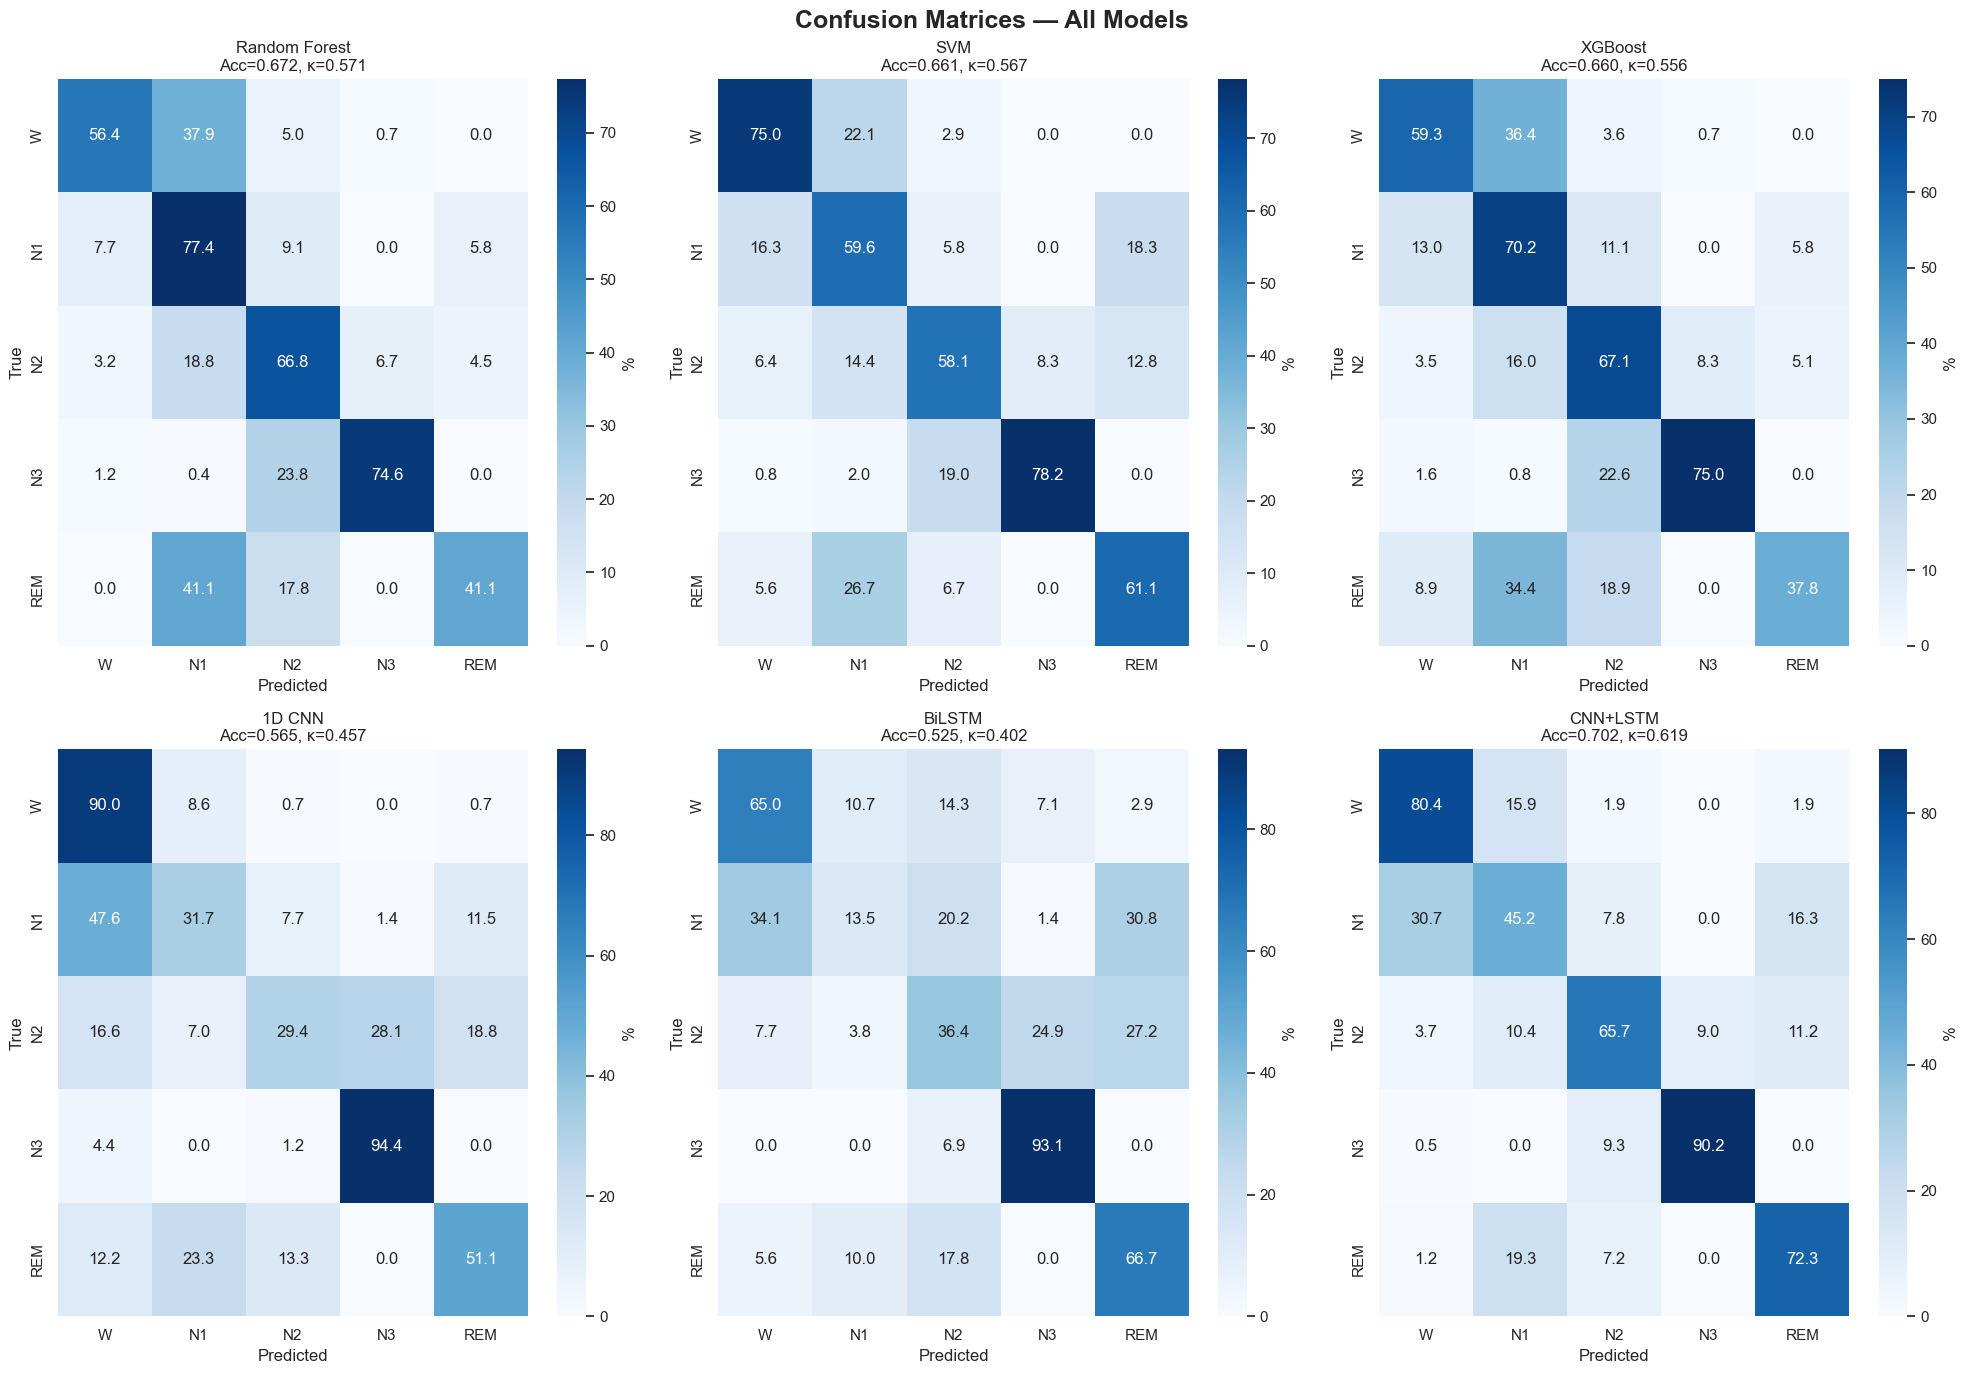

In [23]:
# === CONFUSION MATRICES (2×3 Grid) ===
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
fig.suptitle('Confusion Matrices — All Models', fontsize=18, fontweight='bold')

model_names = list(results.keys())
for idx, (name, ax) in enumerate(zip(model_names, axes.flat)):
    res = results[name]
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    
    # Normalize to percentages (per true class)
    cm_pct = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-8) * 100
    
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
                xticklabels=STAGE_ORDER, yticklabels=STAGE_ORDER,
                cbar_kws={'label': '%'})
    ax.set_title(f'{name}\nAcc={res["accuracy"]:.3f}, κ={res["kappa"]:.3f}', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

# Hide unused subplots if any
for idx in range(len(model_names), 6):
    axes.flat[idx].axis('off')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

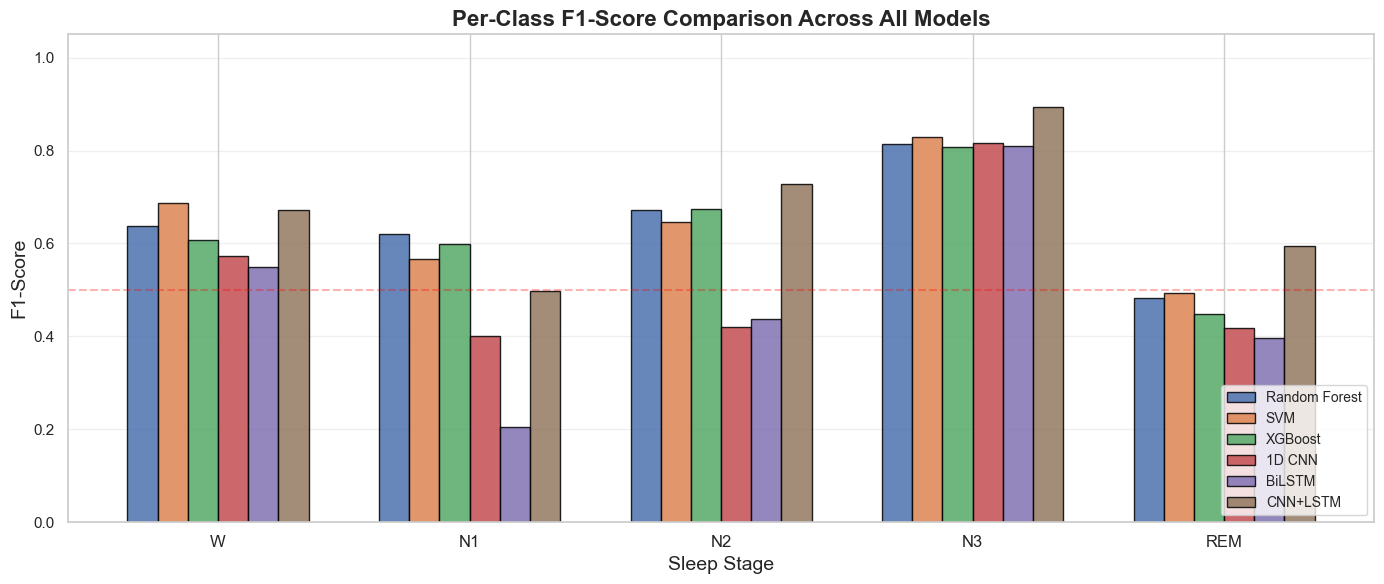

In [24]:
# === PER-CLASS F1-SCORE BAR CHART ===
fig, ax = plt.subplots(figsize=(14, 6))

bar_width = 0.12
x = np.arange(len(STAGE_ORDER))

for i, (name, res) in enumerate(results.items()):
    report = classification_report(res['y_true'], res['y_pred'],
                                   target_names=STAGE_ORDER, output_dict=True)
    f1_scores = [report[stage]['f1-score'] for stage in STAGE_ORDER]
    ax.bar(x + i * bar_width, f1_scores, bar_width, label=name, edgecolor='black', alpha=0.85)

ax.set_xlabel('Sleep Stage', fontsize=14)
ax.set_ylabel('F1-Score', fontsize=14)
ax.set_title('Per-Class F1-Score Comparison Across All Models', fontsize=16, fontweight='bold')
ax.set_xticks(x + bar_width * (len(results) - 1) / 2)
ax.set_xticklabels(STAGE_ORDER, fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(0, 1.05)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.3)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

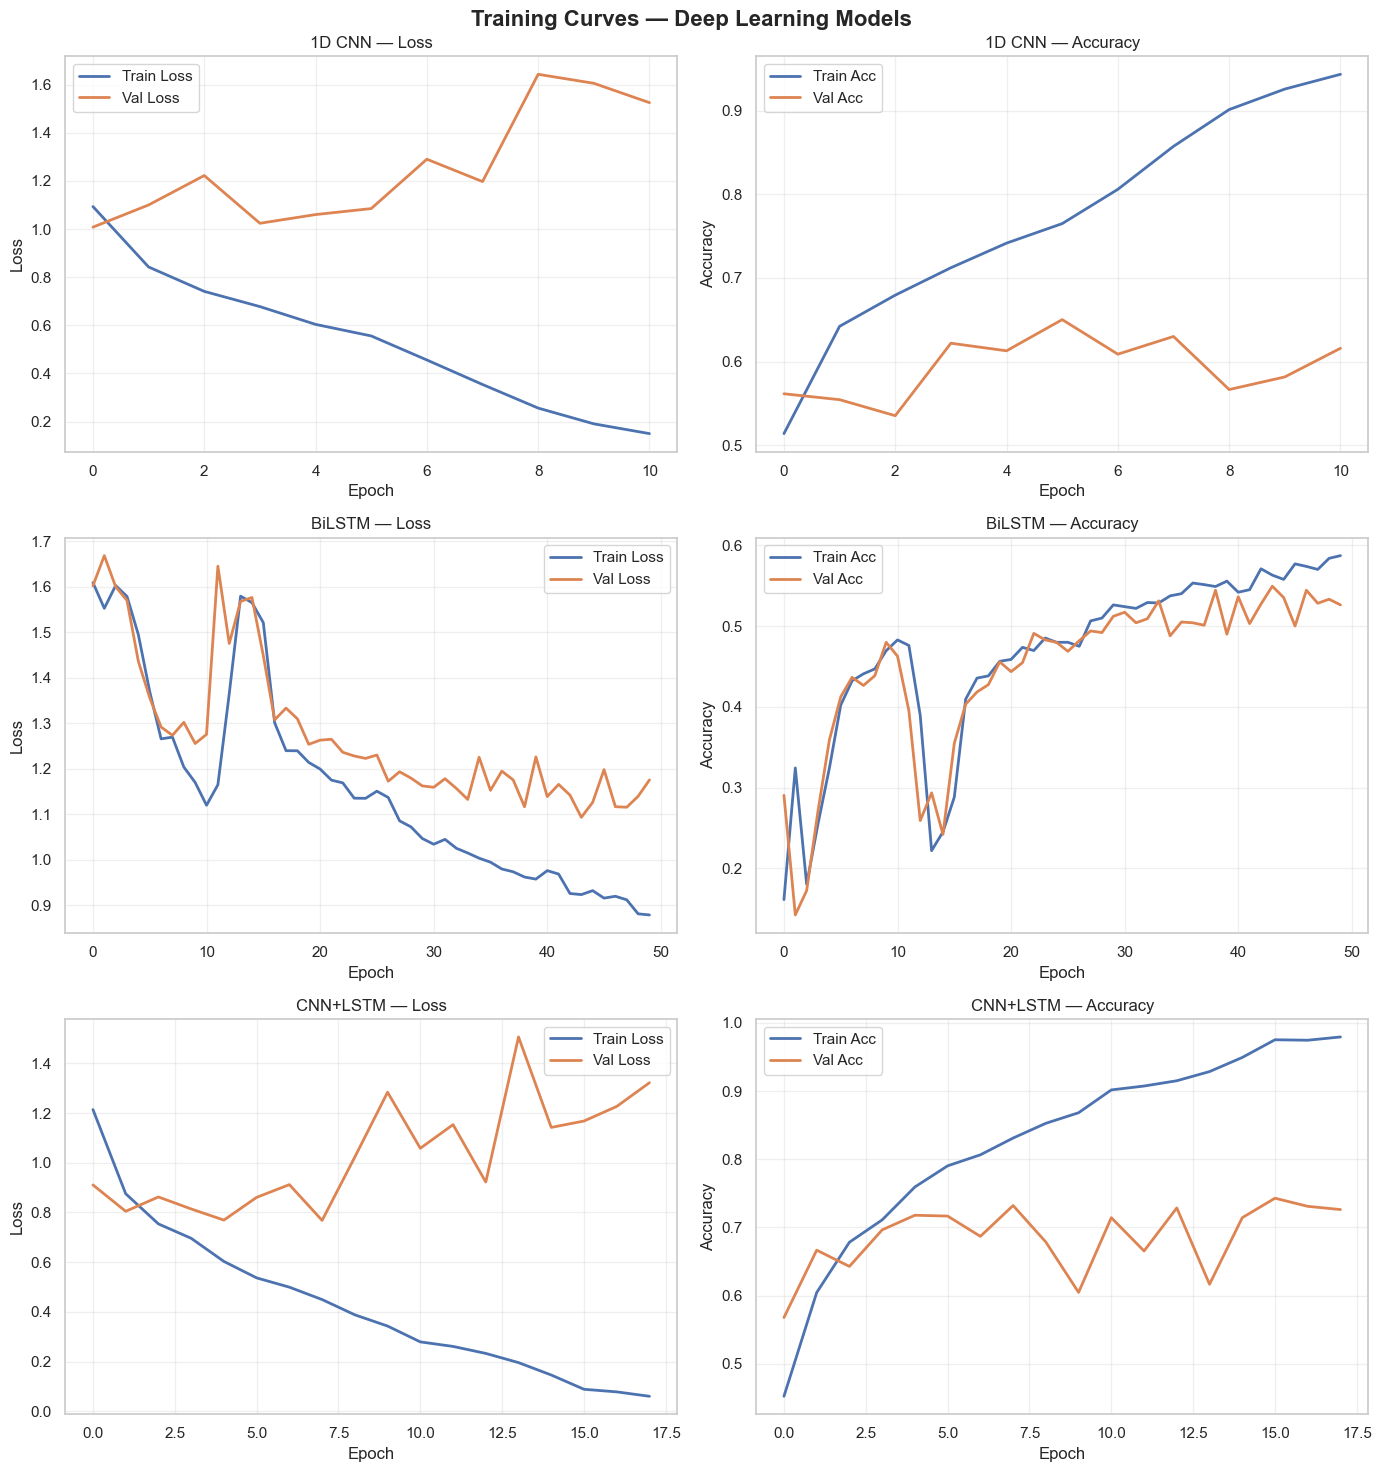

In [25]:
# === TRAINING CURVES (Deep Learning Models) ===
dl_models = {name: res for name, res in results.items() if 'history' in res}

fig, axes = plt.subplots(len(dl_models), 2, figsize=(14, 5 * len(dl_models)))
if len(dl_models) == 1:
    axes = axes.reshape(1, -1)

fig.suptitle('Training Curves — Deep Learning Models', fontsize=16, fontweight='bold')

for idx, (name, res) in enumerate(dl_models.items()):
    hist = res['history']  # PyTorch: already a plain dict
    
    # Loss
    axes[idx, 0].plot(hist['loss'], label='Train Loss', linewidth=2)
    axes[idx, 0].plot(hist['val_loss'], label='Val Loss', linewidth=2)
    axes[idx, 0].set_title(f'{name} — Loss')
    axes[idx, 0].set_xlabel('Epoch')
    axes[idx, 0].set_ylabel('Loss')
    axes[idx, 0].legend()
    axes[idx, 0].grid(alpha=0.3)
    
    # Accuracy
    axes[idx, 1].plot(hist['accuracy'], label='Train Acc', linewidth=2)
    axes[idx, 1].plot(hist['val_accuracy'], label='Val Acc', linewidth=2)
    axes[idx, 1].set_title(f'{name} — Accuracy')
    axes[idx, 1].set_xlabel('Epoch')
    axes[idx, 1].set_ylabel('Accuracy')
    axes[idx, 1].legend()
    axes[idx, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

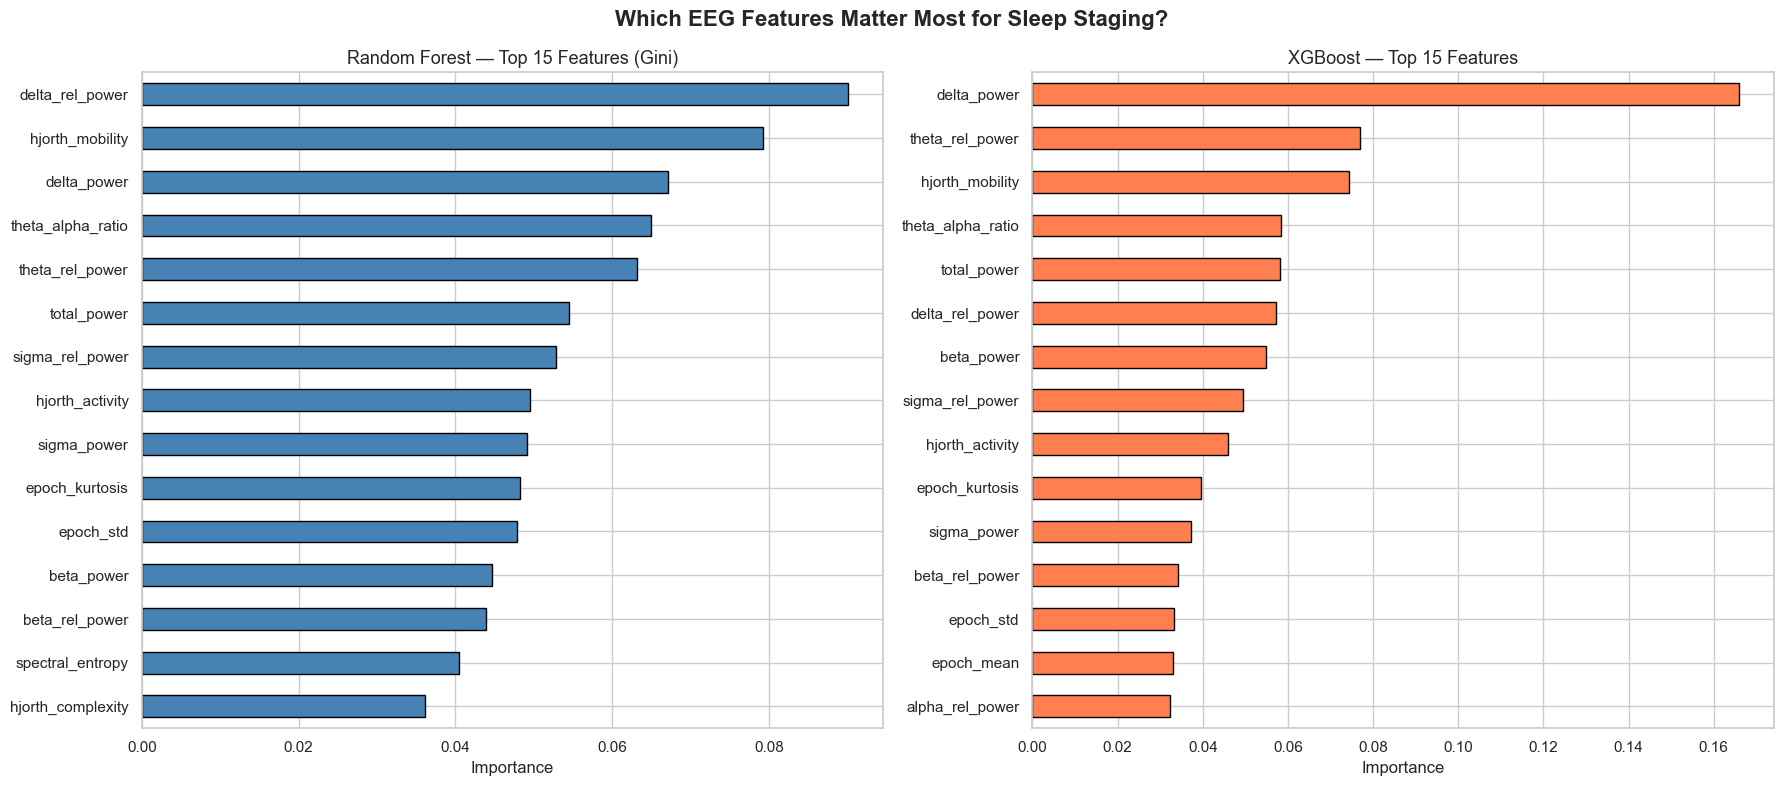

In [26]:
# === FEATURE IMPORTANCE (Random Forest & XGBoost) ===
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Random Forest importances
rf_importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
rf_importances = rf_importances.sort_values(ascending=True).tail(15)
rf_importances.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Random Forest — Top 15 Features (Gini)', fontsize=13)
axes[0].set_xlabel('Importance')

# XGBoost importances
xgb_importances = pd.Series(xgb_model.feature_importances_, index=feature_cols)
xgb_importances = xgb_importances.sort_values(ascending=True).tail(15)
xgb_importances.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('XGBoost — Top 15 Features', fontsize=13)
axes[1].set_xlabel('Importance')

plt.suptitle('Which EEG Features Matter Most for Sleep Staging?', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Using Random Forest for hypnogram visualization (Acc: 0.6717)


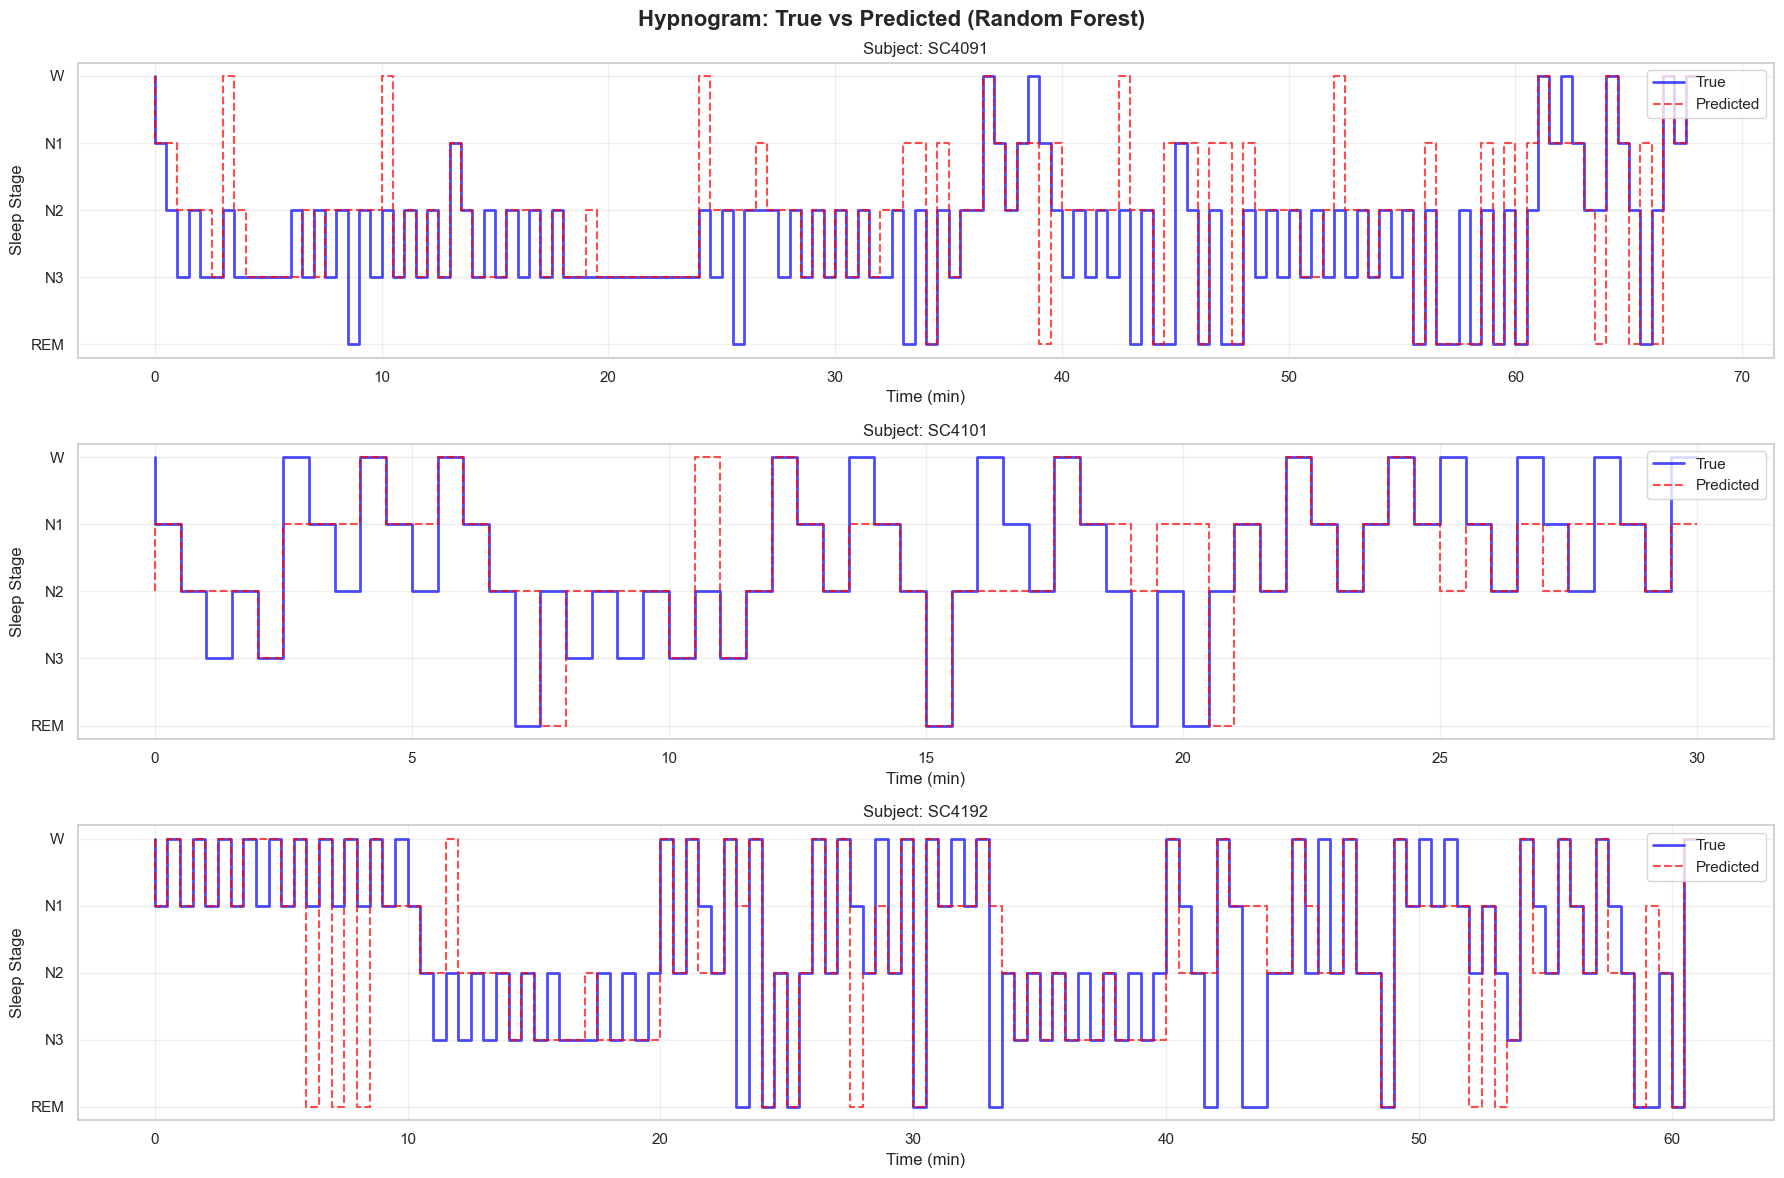

In [27]:
# === HYPNOGRAM VISUALIZATION ===
# Plot predicted vs true sleep stages for test subjects (best standalone model)

# Find best standalone (non-sequence) model for hypnogram plotting
standalone_models = {k: v for k, v in results.items() if k != 'CNN+LSTM'}
best_standalone = max(standalone_models, key=lambda k: standalone_models[k]['accuracy'])
print(f"Using {best_standalone} for hypnogram visualization (Acc: {results[best_standalone]['accuracy']:.4f})")

# Get predictions and true labels
y_pred_viz = results[best_standalone]['y_pred']
y_true_viz = results[best_standalone]['y_true']

# Map test subjects to their epoch indices
if best_standalone in ['1D CNN', 'BiLSTM']:
    test_subjects_arr = subjects_array[test_dl_mask]
else:
    test_subjects_arr = df_features.loc[test_mask, 'subject_id'].values

# Select 3 test subjects for visualization
test_subj_list = list(test_subjects)[:3]

fig, axes = plt.subplots(len(test_subj_list), 1, figsize=(18, 4 * len(test_subj_list)))
if len(test_subj_list) == 1:
    axes = [axes]

fig.suptitle(f'Hypnogram: True vs Predicted ({best_standalone})', fontsize=16, fontweight='bold')

for ax_idx, subj in enumerate(test_subj_list):
    subj_mask = test_subjects_arr == subj
    if subj_mask.sum() == 0:
        continue
    
    true_stages = y_true_viz[subj_mask]
    pred_stages = y_pred_viz[subj_mask]
    time_minutes = np.arange(len(true_stages)) * 0.5  # 30-sec epochs
    
    axes[ax_idx].step(time_minutes, true_stages, label='True', linewidth=2, color='blue', alpha=0.7)
    axes[ax_idx].step(time_minutes, pred_stages, label='Predicted', linewidth=1.5, color='red',
                      linestyle='--', alpha=0.7)
    
    axes[ax_idx].set_yticks(range(5))
    axes[ax_idx].set_yticklabels(STAGE_ORDER)
    axes[ax_idx].invert_yaxis()
    axes[ax_idx].set_xlabel('Time (min)')
    axes[ax_idx].set_ylabel('Sleep Stage')
    axes[ax_idx].set_title(f'Subject: {subj}')
    axes[ax_idx].legend(loc='upper right')
    axes[ax_idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hypnogram_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 7 — Save Outputs

Save the best model, comparison results, and extracted features.

In [28]:
# === SAVE ALL OUTPUTS ===
print("="*60)
print("FINAL SUMMARY")
print("="*60)

# Save comparison results
df_comparison.to_csv('model_comparison_results.csv', index=False)
print("✅ model_comparison_results.csv")

# Save extracted features
df_features.to_csv('eeg_epochs_features.csv', index=False)
print("✅ eeg_epochs_features.csv")

# Save best DL model (PyTorch)
dl_results = {k: v for k, v in results.items() if 'history' in v}
if dl_results:
    best_dl = max(dl_results, key=lambda k: dl_results[k]['accuracy'])
    if best_dl == '1D CNN':
        torch.save(cnn_model.state_dict(), 'best_cnn_model.pt')
        print("✅ best_cnn_model.pt")
    elif best_dl == 'BiLSTM':
        torch.save(bilstm_model.state_dict(), 'best_bilstm_model.pt')
        print("✅ best_bilstm_model.pt")
    elif best_dl == 'CNN+LSTM':
        print("✅ best_cnn_lstm_model.pt (saved during training)")

# Overall best
best_overall = max(results, key=lambda k: results[k]['accuracy'])
print(f"\n{'='*60}")
print(f"🏆 BEST MODEL: {best_overall}")
print(f"   Accuracy:      {results[best_overall]['accuracy']:.4f}")
print(f"   F1 (Macro):    {results[best_overall]['f1_macro']:.4f}")
print(f"   Cohen's Kappa: {results[best_overall]['kappa']:.4f}")
print(f"{'='*60}")

# Check all saved files
print("\nSaved files:")
output_files = ['model_comparison_results.csv', 'eeg_epochs_features.csv',
                'class_distribution.png', 'confusion_matrices.png', 'per_class_f1.png',
                'training_curves.png', 'feature_importance.png', 'hypnogram_comparison.png',
                'best_cnn_lstm_model.pt', 'best_cnn_model.pt', 'best_bilstm_model.pt']
for f in output_files:
    if os.path.exists(f):
        size_kb = os.path.getsize(f) / 1024
        print(f"  ✅ {f} ({size_kb:.0f} KB)")

FINAL SUMMARY
✅ model_comparison_results.csv
✅ eeg_epochs_features.csv
✅ best_cnn_lstm_model.pt (saved during training)

🏆 BEST MODEL: CNN+LSTM
   Accuracy:      0.7017
   F1 (Macro):    0.6766
   Cohen's Kappa: 0.6191

Saved files:
  ✅ model_comparison_results.csv (0 KB)
  ✅ eeg_epochs_features.csv (3014 KB)
  ✅ class_distribution.png (100 KB)
  ✅ confusion_matrices.png (279 KB)
  ✅ per_class_f1.png (68 KB)
  ✅ training_curves.png (385 KB)
  ✅ feature_importance.png (146 KB)
  ✅ hypnogram_comparison.png (250 KB)
  ✅ best_cnn_lstm_model.pt (1373 KB)


# Phase 8 — Bridge to Lifestyle Analysis
Generate per-subject sleep quality metrics from the EEG staging results.  
This produces `eeg_sleep_quality.csv` which is consumed by `lifestyle.ipynb`.

In [30]:
# ── Compute per-subject sleep-quality metrics ───────────────
# Uses the best-performing model's predictions on the TEST set
# to derive clinically-meaningful sleep architecture features.

best_model_name = max(results, key=lambda k: results[k]['kappa'])
print(f"Using predictions from: {best_model_name}")

# Get test predictions - use the stored y_pred and y_true from the best model
y_true_best = results[best_model_name]['y_true']
y_pred_best = results[best_model_name]['y_pred']

# Build per-subject metrics from test subjects
test_subj_ids = df_features.loc[df_features['subject_id'].isin(test_subjects), 'subject_id'].unique()

epoch_dur = 30  # seconds

bridge_records = []
for sid in test_subj_ids:
    mask = df_features['subject_id'] == sid

    # Safer: directly use the features dataframe to get subject epochs
    subj_epochs = df_features.loc[mask]
    if len(subj_epochs) == 0:
        continue

    # Use integer stage labels
    true_stages = subj_epochs['stage_int'].values
    n_epochs = len(true_stages)
    total_time_min = n_epochs * epoch_dur / 60

    # Sleep architecture from true labels
    n_w = np.sum(true_stages == 0)
    n_n1 = np.sum(true_stages == 1)
    n_n2 = np.sum(true_stages == 2)
    n_n3 = np.sum(true_stages == 3)
    n_rem = np.sum(true_stages == 4)
    n_sleep = n_n1 + n_n2 + n_n3 + n_rem

    tst_min = n_sleep * epoch_dur / 60
    efficiency = (n_sleep / n_epochs * 100) if n_epochs > 0 else 0

    # Sleep onset latency (epochs of W before first sleep)
    sleep_onset = np.argmax(true_stages > 0) if np.any(true_stages > 0) else n_epochs
    sol_min = sleep_onset * epoch_dur / 60

    # WASO: wake epochs AFTER first sleep and BEFORE last sleep
    if np.any(true_stages > 0):
        first_sleep = np.argmax(true_stages > 0)
        last_sleep = n_epochs - 1 - np.argmax(true_stages[::-1] > 0)
        waso_epochs = np.sum(true_stages[first_sleep:last_sleep+1] == 0)
        waso_min = waso_epochs * epoch_dur / 60
    else:
        waso_min = 0

    # Stage percentages (of TST)
    pct_n1 = (n_n1 / n_sleep * 100) if n_sleep > 0 else 0
    pct_n2 = (n_n2 / n_sleep * 100) if n_sleep > 0 else 0
    pct_n3 = (n_n3 / n_sleep * 100) if n_sleep > 0 else 0
    pct_rem = (n_rem / n_sleep * 100) if n_sleep > 0 else 0

    # Awakenings: transitions from sleep stage to W
    awakenings = np.sum((true_stages[1:] == 0) & (true_stages[:-1] > 0))

    # Stage transitions (total)
    n_transitions = np.sum(np.diff(true_stages) != 0)

    # Composite Sleep Quality Score (0-100)
    eff_score = min(efficiency, 100) / 100 * 40
    deep_score = min(pct_n3, 25) / 25 * 20
    rem_score = min(pct_rem, 25) / 25 * 20
    sol_score = max(0, 10 - sol_min) / 10 * 10
    awak_per_hr = (awakenings / (tst_min / 60)) if tst_min > 0 else 99
    cont_score = max(0, 10 - awak_per_hr) / 10 * 10
    quality_score = eff_score + deep_score + rem_score + sol_score + cont_score

    bridge_records.append({
        'subject_id': sid,
        'total_recording_min': round(total_time_min, 1),
        'tst_min': round(tst_min, 1),
        'efficiency_pct': round(efficiency, 1),
        'sol_min': round(sol_min, 1),
        'waso_min': round(waso_min, 1),
        'pct_N1': round(pct_n1, 1),
        'pct_N2': round(pct_n2, 1),
        'pct_N3': round(pct_n3, 1),
        'pct_REM': round(pct_rem, 1),
        'awakenings': int(awakenings),
        'stage_transitions': int(n_transitions),
        'sleep_quality_score': round(quality_score, 1),
    })

df_bridge = pd.DataFrame(bridge_records)
print(f"\nBridge dataset: {len(df_bridge)} subjects")
df_bridge.describe().round(1)

Using predictions from: CNN+LSTM

Bridge dataset: 9 subjects


,total_recording_min,tst_min,efficiency_pct,sol_min,waso_min,pct_N1,pct_N2,pct_N3,pct_REM,awakenings,stage_transitions,sleep_quality_score
count,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0
mean,55.5,47.7,85.7,0.5,6.8,25.1,37.5,27.4,10.0,14.6,95.3,68.5
std,13.0,12.5,8.0,0.0,4.9,12.4,7.3,15.2,3.8,9.8,23.3,9.5
min,30.5,23.5,72.4,0.5,1.5,7.8,28.3,1.0,3.0,4.0,60.0,53.9
25%,55.0,44.5,78.2,0.5,3.5,18.3,30.3,19.1,8.1,8.0,80.0,64.5
50%,61.0,52.0,88.0,0.5,5.5,21.2,40.4,30.3,10.0,12.0,92.0,67.3
75%,61.5,54.5,90.0,0.5,7.5,30.3,42.4,39.1,13.2,16.0,112.0,74.0
max,68.5,64.5,95.7,0.5,16.0,51.9,46.8,47.2,15.4,33.0,132.0,81.4


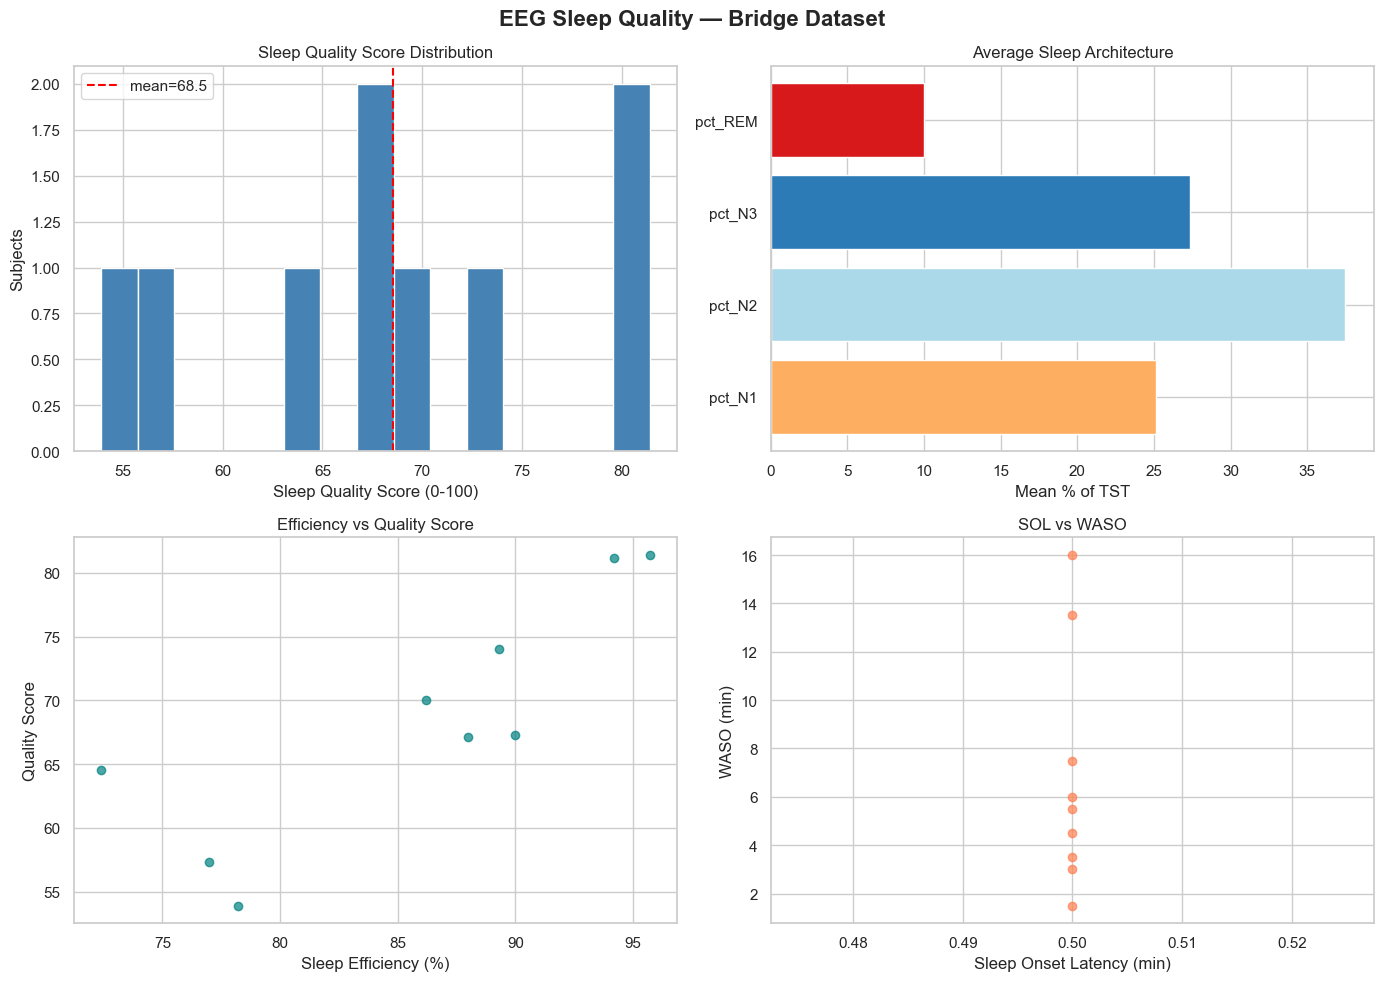

✅ eeg_sleep_quality.csv saved — 9 subjects
✅ bridge_sleep_quality.png saved

→ Next step: open lifestyle.ipynb — it will load this CSV in Part B.


In [31]:
# ── Visualise & save the bridge CSV ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EEG Sleep Quality — Bridge Dataset', fontsize=16, fontweight='bold')

# 1. Quality score distribution
axes[0, 0].hist(df_bridge['sleep_quality_score'], bins=15, color='steelblue', edgecolor='white')
axes[0, 0].set_xlabel('Sleep Quality Score (0-100)')
axes[0, 0].set_ylabel('Subjects')
axes[0, 0].set_title('Sleep Quality Score Distribution')
axes[0, 0].axvline(df_bridge['sleep_quality_score'].mean(), color='red', ls='--',
                    label=f"mean={df_bridge['sleep_quality_score'].mean():.1f}")
axes[0, 0].legend()

# 2. Stage percentages (stacked)
stage_cols = ['pct_N1', 'pct_N2', 'pct_N3', 'pct_REM']
stage_means = df_bridge[stage_cols].mean()
colors = ['#fdae61', '#abd9e9', '#2c7bb6', '#d7191c']
axes[0, 1].barh(stage_cols, stage_means, color=colors, edgecolor='white')
axes[0, 1].set_xlabel('Mean % of TST')
axes[0, 1].set_title('Average Sleep Architecture')

# 3. Efficiency vs Quality
axes[1, 0].scatter(df_bridge['efficiency_pct'], df_bridge['sleep_quality_score'],
                    alpha=0.7, color='teal')
axes[1, 0].set_xlabel('Sleep Efficiency (%)')
axes[1, 0].set_ylabel('Quality Score')
axes[1, 0].set_title('Efficiency vs Quality Score')

# 4. SOL vs WASO
axes[1, 1].scatter(df_bridge['sol_min'], df_bridge['waso_min'],
                    alpha=0.7, color='coral')
axes[1, 1].set_xlabel('Sleep Onset Latency (min)')
axes[1, 1].set_ylabel('WASO (min)')
axes[1, 1].set_title('SOL vs WASO')

plt.tight_layout()
plt.savefig('bridge_sleep_quality.png', dpi=150, bbox_inches='tight')
plt.show()

# Save the bridge CSV
df_bridge.to_csv('eeg_sleep_quality.csv', index=False)
print("✅ eeg_sleep_quality.csv saved —", len(df_bridge), "subjects")
print("✅ bridge_sleep_quality.png saved")
print("\n→ Next step: open lifestyle.ipynb — it will load this CSV in Part B.")